# Explaining the data

Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers

X1 = my order was delivered on time

X2 = contents of my order was as I expected

X3 = I ordered everything I wanted to order

X4 = I paid a good price for my order

X5 = I am satisfied with my courier

X6 = the app makes ordering easy for me

X ranked from 1-5 where 5 is an accurate statement and 1 is inaccurate

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import seaborn as sns

In [12]:
# importing the data into data frame
filename = r"../../data/raw/ACME-HappinessSurvey2020.csv"
df = pd.read_csv(filename)
# for x in ["X1", "X2", "X3", "X4", "X5", "X6"]:
#     df[x] = pd.Categorical(df[x],
#                            categories=[1,2,3,4,5],
#                            ordered=True
#                            )
df.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Qualitative notes: 

X1 is largely at 5, with most of the data at 5 (the highest score). this means that most pckages are delivered on time (at least 50%). 75% of packages are delivered near on time (4).

X2 has the least amount of high scores with 75% scoring 3 or lower. This means that largely people disagreed with the aspect that the contents of their order were as expected... Unsure what this means physically.

X3, X4 and X5 seem to have mid ratings. "I ordered everything that I wanted to order", "I paid a good price for my order," and "I am satisfied with my courier." 

X6 also seems to have good ratings. "the app makes ordering easy for me."

# Null Handling

In [13]:
number_of_nulls = 0
for col in df:
    number_of_nulls += df[col].isnull().sum()
print(f"Nulls present: {bool(number_of_nulls)}")

Nulls present: False


___

# Descriptive figures

___

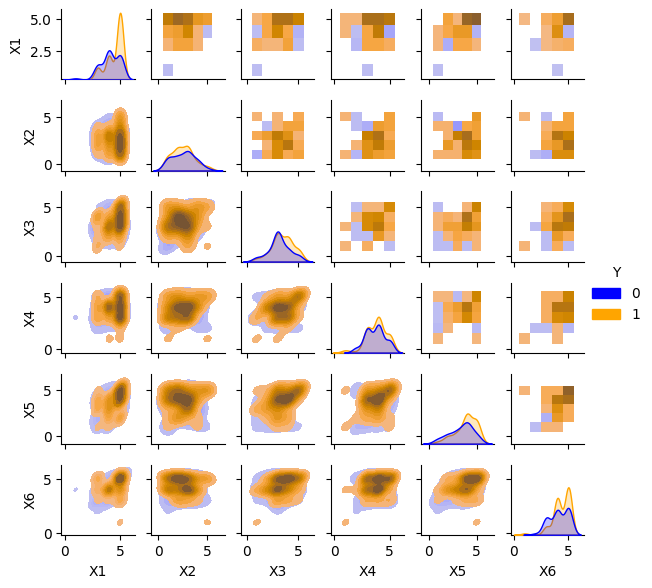

In [14]:
palette = {0: "blue", 1: "orange"}

g = sns.PairGrid(data=df, hue="Y", hue_order=[0, 1], palette=palette,height=1, aspect=1)
g.map_upper(sns.histplot, discrete=True, palette=palette)
g.map_lower(sns.kdeplot, fill=True, palette=palette)
# g.map_diag(sns.histplot, discrete=True, palette=palette)
g.map_diag(sns.kdeplot, palette = palette, fill=True)
g.add_legend()


# Checking for correlation between variables

           Y        X1        X2        X3        X4        X5        X6
Y   1.000000  0.280160 -0.024274  0.150838  0.064415  0.224522  0.167669
X1  0.280160  1.000000  0.059797  0.283358  0.087541  0.432772  0.411873
X2 -0.024274  0.059797  1.000000  0.184129  0.114838  0.039996 -0.062205
X3  0.150838  0.283358  0.184129  1.000000  0.302618  0.358397  0.203750
X4  0.064415  0.087541  0.114838  0.302618  1.000000  0.293115  0.215888
X5  0.224522  0.432772  0.039996  0.358397  0.293115  1.000000  0.320195
X6  0.167669  0.411873 -0.062205  0.203750  0.215888  0.320195  1.000000


Text(0.5, 1.0, 'Correlation Matrix')

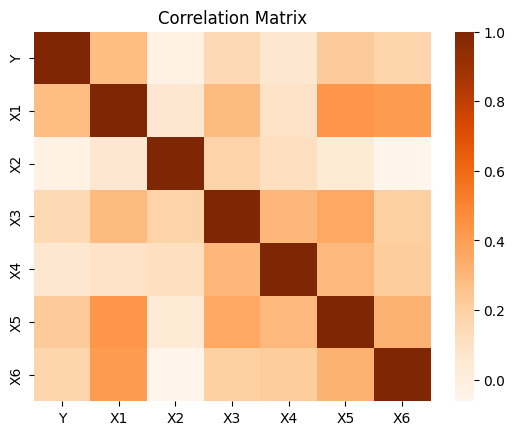

In [15]:
# beyond .6 is pretty correlated. do not want Xs to correlate
print(df.corr())
sns.color_palette("Oranges", as_cmap=True)
sns.heatmap(df.corr(), cmap="Oranges")
plt.title("Correlation Matrix")

In [16]:
df

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5
...,...,...,...,...,...,...,...
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5


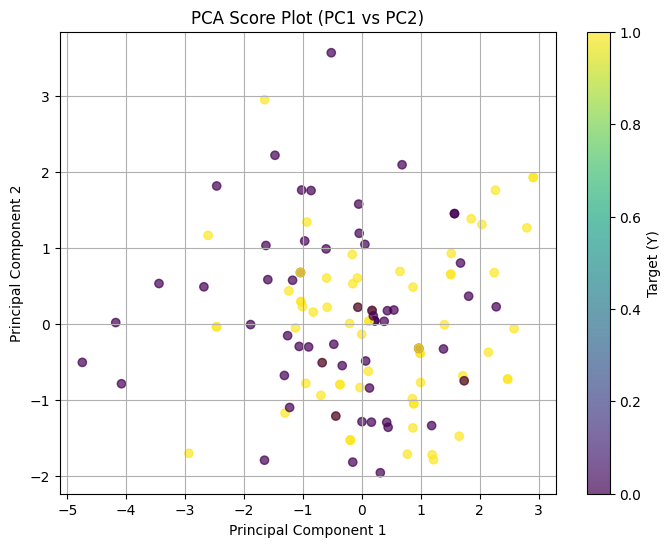

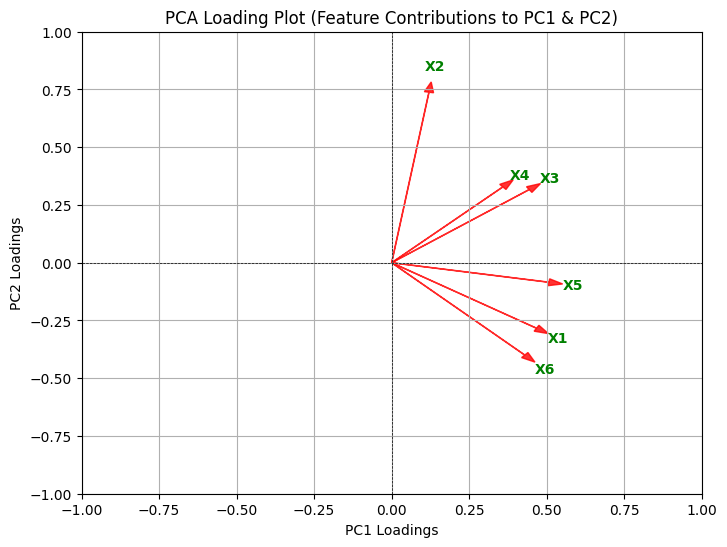


Loadings Matrix for all 6 PCs:
           X1        X2        X3        X4        X5        X6
PC1  0.467272  0.120344  0.443685  0.358668  0.507255  0.429380
PC2 -0.283589  0.738073  0.316632  0.328158 -0.084543 -0.399668
PC3 -0.482292 -0.503060  0.029273  0.716117  0.013436  0.021544
PC4 -0.003015  0.391102 -0.530419  0.282488 -0.340608  0.608171
PC5 -0.112441 -0.111404  0.646840 -0.179898 -0.622090  0.370385
PC6  0.675260 -0.149414 -0.047801  0.372401 -0.482032 -0.385197


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Assume 'df' contains columns X1 to X6 and your target column 'y'
# df = pd.read_csv('your_data.csv')

# 2. Separate features and target
features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
x = df[features].values
y = df['Y'].values

# 3. Standardize the data
x_scaled = StandardScaler().fit_transform(x)

# 4. Keep all 6 components
pca = PCA(n_components=6)
principal_components = pca.fit_transform(x_scaled)

# 5. Create a DataFrame for all 6 PCs
pc_columns = [f'PC{i+1}' for i in range(6)]
pca_df = pd.DataFrame(data=principal_components, columns=pc_columns)
pca_df['Y'] = y

# ==========================================
# PLOT 1: PCA Score Plot (Colored by Target 'Y')
# ==========================================
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df['PC1'], pca_df['PC2'], c=pca_df['Y'], cmap='viridis', alpha=0.7
)
plt.colorbar(scatter, label='Target (Y)')
plt.title('PCA Score Plot (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# ==========================================
# PLOT 2: PCA Loading Plot (PC1 vs PC2)
# ==========================================
loadings = pca.components_  # Shape: (6, 6) -> (n_components, n_features)

plt.figure(figsize=(8, 6))
# Plot vectors from the origin for PC1 and PC2
for i, feature in enumerate(features):
    plt.arrow(
        0,
        0,
        loadings[0, i],
        loadings[1, i],
        color='r',
        alpha=0.8,
        head_width=0.03,
    )
    plt.text(
        loadings[0, i] * 1.15,
        loadings[1, i] * 1.15,
        feature,
        color='g',
        ha='center',
        va='center',
        fontweight='bold',
    )

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.title('PCA Loading Plot (Feature Contributions to PC1 & PC2)')
plt.xlabel('PC1 Loadings')
plt.ylabel('PC2 Loadings')
plt.grid(True)
plt.show()

# Optional: Print the full loadings matrix for all 6 PCs
loadings_df = pd.DataFrame(loadings, columns=features, index=pc_columns)
print('\nLoadings Matrix for all 6 PCs:')
print(loadings_df)

In [23]:
print("--- PCA Linear Combinations (Equations) ---\n")
print("Note: Features (X1-X6) are standardized (mean=0, variance=1).\n")

# Loop through each component to build and print the mathematical string
for i, component_weights in enumerate(pca.components_):
    pc_num = i + 1
    equation_parts = []

    for weight, feature_name in zip(component_weights, features):
        # Format the weight to 3 decimal places
        # Add a leading plus sign if the weight is positive
        sign = " + " if weight >= 0 else " - "
        equation_parts.append(f"{sign}{abs(weight):.3f} * {feature_name}")

    # Combine parts into a single string equation
    equation_string = "".join(equation_parts)

    # Clean up the very first leading '+' if present
    if equation_string.startswith(" + "):
        equation_string = equation_string[3:]
    elif equation_string.startswith(" - "):
        equation_string = "-" + equation_string[3:]

    print(f"PC{pc_num} = {equation_string}")

# Optional: Display as a clean DataFrame summary
print("\n--- Weights DataFrame Summary ---")
pc_columns = [f"PC{i+1}" for i in range(6)]
weights_df = pd.DataFrame(pca.components_, columns=features, index=pc_columns)
weights_df.round(3)

--- PCA Linear Combinations (Equations) ---

Note: Features (X1-X6) are standardized (mean=0, variance=1).

PC1 = 0.467 * X1 + 0.120 * X2 + 0.444 * X3 + 0.359 * X4 + 0.507 * X5 + 0.429 * X6
PC2 = -0.284 * X1 + 0.738 * X2 + 0.317 * X3 + 0.328 * X4 - 0.085 * X5 - 0.400 * X6
PC3 = -0.482 * X1 - 0.503 * X2 + 0.029 * X3 + 0.716 * X4 + 0.013 * X5 + 0.022 * X6
PC4 = -0.003 * X1 + 0.391 * X2 - 0.530 * X3 + 0.282 * X4 - 0.341 * X5 + 0.608 * X6
PC5 = -0.112 * X1 - 0.111 * X2 + 0.647 * X3 - 0.180 * X4 - 0.622 * X5 + 0.370 * X6
PC6 = 0.675 * X1 - 0.149 * X2 - 0.048 * X3 + 0.372 * X4 - 0.482 * X5 - 0.385 * X6

--- Weights DataFrame Summary ---


,X1,X2,X3,X4,X5,X6
PC1,0.467,0.120,0.444,0.359,0.507,0.429
PC2,-0.284,0.738,0.317,0.328,-0.085,-0.400
PC3,-0.482,-0.503,0.029,0.716,0.013,0.022
PC4,-0.003,0.391,-0.530,0.282,-0.341,0.608
PC5,-0.112,-0.111,0.647,-0.180,-0.622,0.370
PC6,0.675,-0.149,-0.048,0.372,-0.482,-0.385


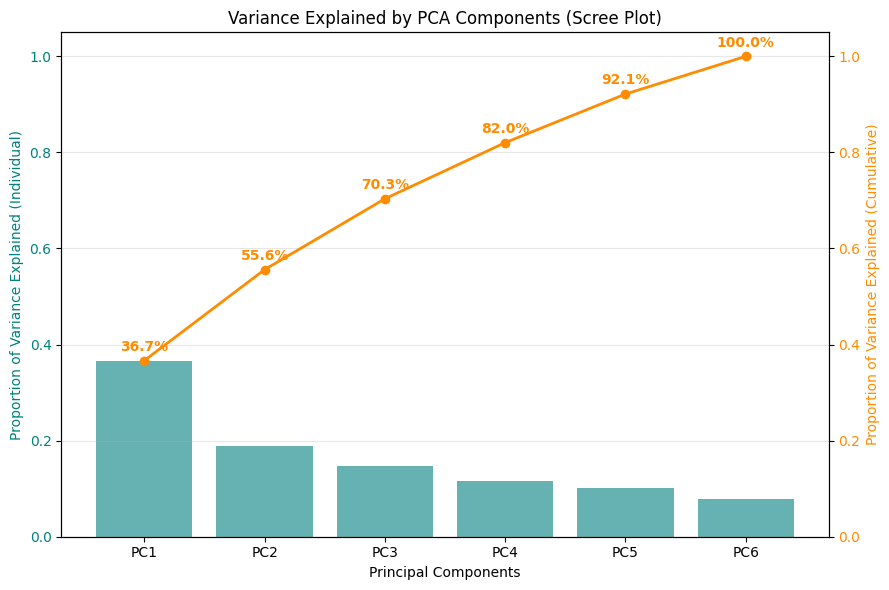

--- Variance Summary ---
PC1: Individual = 36.7% | Cumulative = 36.7%
PC2: Individual = 18.9% | Cumulative = 55.6%
PC3: Individual = 14.7% | Cumulative = 70.3%
PC4: Individual = 11.7% | Cumulative = 82.0%
PC5: Individual = 10.1% | Cumulative = 92.1%
PC6: Individual = 7.9% | Cumulative = 100.0%


In [20]:
# 4. Extract variance ratios
exp_var_individual = pca.explained_variance_ratio_
exp_var_cumulative = np.cumsum(exp_var_individual)

# ==========================================
# PLOT: Variance Explained (Scree Plot)
# ==========================================
fig, ax1 = plt.subplots(figsize=(9, 6))

# Primary Axis: Bar chart for individual variance
pc_labels = [f"PC{i+1}" for i in range(6)]
bars = ax1.bar(
    pc_labels,
    exp_var_individual,
    alpha=0.6,
    color="teal",
    label="Individual Variance",
)
ax1.set_xlabel("Principal Components")
ax1.set_ylabel("Proportion of Variance Explained (Individual)", color="teal")
ax1.tick_params(axis="y", labelcolor="teal")
ax1.set_ylim(0, 1.05)

# Secondary Axis: Line chart for cumulative variance
ax2 = ax1.twinx()
(line,) = ax2.plot(
    pc_labels,
    exp_var_cumulative,
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Cumulative Variance",
)
ax2.set_ylabel("Proportion of Variance Explained (Cumulative)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, 1.05)

# Add values on top of the cumulative dots for clarity
for i, val in enumerate(exp_var_cumulative):
    ax2.text(
        i,
        val + 0.02,
        f"{val*100:.1f}%",
        color="darkorange",
        ha="center",
        fontweight="bold",
    )

# Formatting
plt.title("Variance Explained by PCA Components (Scree Plot)")
fig.tight_layout()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Print a quick text summary
print("--- Variance Summary ---")
for i in range(6):
    print(
        f"PC{i+1}: Individual = {exp_var_individual[i]*100:.1f}% | Cumulative = {exp_var_cumulative[i]*100:.1f}%"
    )